<a href="https://colab.research.google.com/github/AngeloSorte/nasa-climate-anomaly-detection/blob/angelosorte.github.io/Climate_Anomaly_Detection_with_NASA_GISS_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Colonne disponibili nel CSV: ['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'J-D', 'D-N', 'DJF', 'MAM', 'JJA', 'SON']


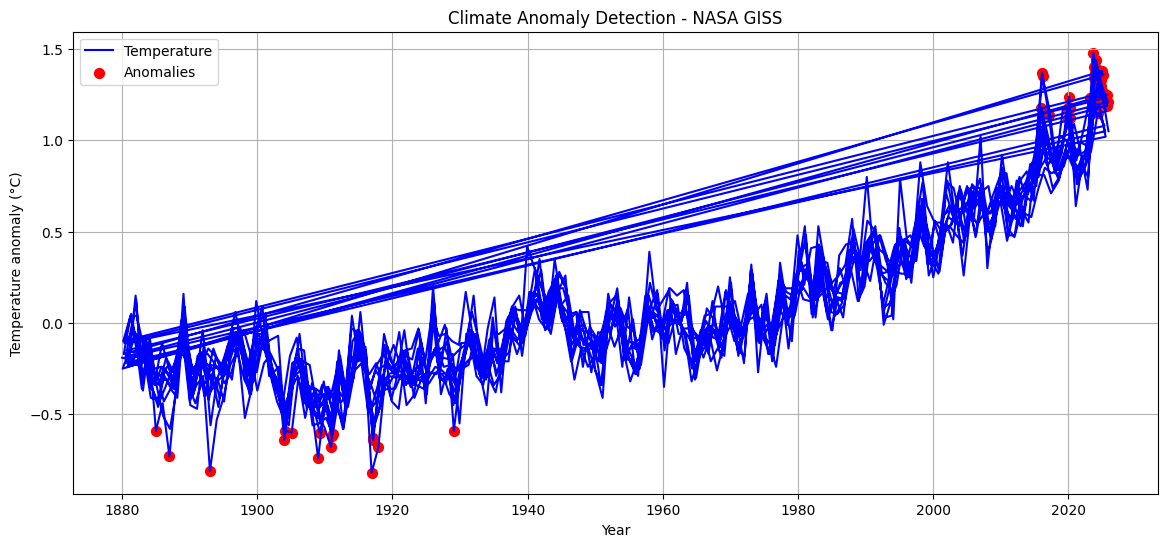

Numero di anomalie individuate: 51


In [2]:
# ===============================
# Climate Anomaly Detection - NASA GISS Data
# Isolation Forest | Interpretable ML
# ===============================

# 1️⃣ Installare pacchetti necessari (Colab)
!pip install pandas matplotlib scikit-learn --quiet

# 2️⃣ Importare librerie
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# 3️⃣ Scaricare dataset NASA GISS Surface Temperature (GISTEMP)
url = "https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv"
df = pd.read_csv(url, skiprows=1)  # Salta la riga di intestazione extra

# 4️⃣ Controllare colonne disponibili
print("Colonne disponibili nel CSV:", df.columns.tolist())

# 5️⃣ Selezionare solo Year e mesi
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
columns_to_keep = ['Year'] + [m for m in months if m in df.columns]
df = df[columns_to_keep]

# 6️⃣ Trasformare da wide a long (Year + Month + Temp)
df = df.melt(id_vars=["Year"], var_name="Month", value_name="Temp")
df['Temp'] = pd.to_numeric(df['Temp'], errors='coerce')
df = df.dropna().reset_index(drop=True)

# 7️⃣ Feature engineering - indice temporale continuo
df['TimeIndex'] = df['Year'] + (df['Month'].map(lambda x: months.index(x))/12)

# 8️⃣ Modello Isolation Forest per anomaly detection
model = IsolationForest(contamination=0.03, random_state=42)
df['Anomaly'] = model.fit_predict(df[['Temp']])
# Anomalie = -1, normali = 1

# 9️⃣ Visualizzazione grafica
plt.figure(figsize=(14,6))
plt.plot(df['TimeIndex'], df['Temp'], label='Temperature', color='blue')
plt.scatter(df[df['Anomaly']==-1]['TimeIndex'],
            df[df['Anomaly']==-1]['Temp'],
            color='red', label='Anomalies', s=50)
plt.xlabel("Year")
plt.ylabel("Temperature anomaly (°C)")
plt.title("Climate Anomaly Detection - NASA GISS")
plt.legend()
plt.grid(True)
plt.show()

# 🔟 Breve statistica
n_anomalies = sum(df['Anomaly']==-1)
print(f"Numero di anomalie individuate: {n_anomalies}")
